In [1]:
from ultralytics import YOLO

best_model_path = r"D:\Smartvision_project\runs\detect\smartvision_yolo\yolov8n_25class\weights\best.pt"

best_model = YOLO(best_model_path)

print("✅ Best YOLO model loaded!")
print(best_model_path)

✅ Best YOLO model loaded!
D:\Smartvision_project\runs\detect\smartvision_yolo\yolov8n_25class\weights\best.pt


In [2]:
metrics = best_model.val(
    data=yaml_path,
    imgsz=640,
    batch=8
)

print("\n========== YOLO EVALUATION ==========")
print("Precision :", metrics.box.mp)
print("Recall    :", metrics.box.mr)
print("mAP@0.5   :", metrics.box.map50)
print("mAP@0.5:0.95:", metrics.box.map)

NameError: name 'yaml_path' is not defined

In [3]:
from ultralytics import YOLO

# Load best trained model
best_model_path = r"D:\Smartvision_project\runs\detect\smartvision_yolo\yolov8n_25class\weights\best.pt"
best_model = YOLO(best_model_path)

# Dataset configuration
data_yaml = r"D:\Smartvision_project\smartvision_dataset\detection\data.yaml"

# Evaluate
metrics = best_model.val(
    data=data_yaml,
    imgsz=640,
    batch=8
)

print("\n========== YOLO EVALUATION ==========")
print(f"Precision       : {metrics.box.mp:.4f}")
print(f"Recall          : {metrics.box.mr:.4f}")
print(f"mAP@0.5         : {metrics.box.map50:.4f}")
print(f"mAP@0.5:0.95    : {metrics.box.map:.4f}")

Ultralytics 8.4.137  Python-3.13.9 torch-2.13.0+cpu CPU (Intel Core i5-6300U 2.40GHz)
Model summary (fused): 73 layers, 3,010,523 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 269.2232.0 MB/s, size: 120.6 KB)
val: Scanning D:\Smartvision_project\smartvision_dataset\detection\val\labels.cache... 425 images, 0 backgrounds, 334 corrupt: 100% ━━━━━━━━━━━━ 425/425 84.9Mit/s 0.0s
val: D:\Smartvision_project\smartvision_dataset\detection\val\images\image_000002.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [1.0362   1.3258   1.133727 1.02763  1.02652  1.384619]
val: D:\Smartvision_project\smartvision_dataset\detection\val\images\image_000005.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [1.0362   1.3258   1.133727 1.02763  1.02652  1.384619]
val: D:\Smartvision_project\smartvision_dataset\detection\val\images\image_000010.jpg: ignoring corrupt image/label: non-normalized or out of bounds co

In [4]:
print("========== PER-CLASS RESULTS ==========")

class_names = best_model.names

for i, name in class_names.items():
    print(
        f"{i:2d} | {name:15s} | "
        f"Precision: {metrics.box.p[i]:.3f} | "
        f"Recall: {metrics.box.r[i]:.3f} | "
        f"mAP50: {metrics.box.ap50[i]:.3f} | "
        f"mAP50-95: {metrics.box.ap[i]:.3f}"
    )

========== PER-CLASS RESULTS ==========
 0 | person          | Precision: 0.649 | Recall: 0.154 | mAP50: 0.325 | mAP50-95: 0.135
 1 | bicycle         | Precision: 0.468 | Recall: 0.733 | mAP50: 0.751 | mAP50-95: 0.430
 2 | car             | Precision: 0.384 | Recall: 0.350 | mAP50: 0.352 | mAP50-95: 0.100
 3 | motorcycle      | Precision: 0.000 | Recall: 0.000 | mAP50: 0.000 | mAP50-95: 0.000
 4 | airplane        | Precision: 0.178 | Recall: 0.529 | mAP50: 0.368 | mAP50-95: 0.122
 5 | bus             | Precision: 0.777 | Recall: 0.714 | mAP50: 0.693 | mAP50-95: 0.319
 6 | truck           | Precision: 0.380 | Recall: 1.000 | mAP50: 0.828 | mAP50-95: 0.149
 7 | traffic light   | Precision: 0.332 | Recall: 0.500 | mAP50: 0.650 | mAP50-95: 0.320
 8 | stop sign       | Precision: 0.225 | Recall: 0.429 | mAP50: 0.378 | mAP50-95: 0.166
 9 | bench           | Precision: 0.212 | Recall: 0.273 | mAP50: 0.178 | mAP50-95: 0.059
10 | bird            | Precision: 0.240 | Recall: 0.352 | mAP50: 0.325

In [5]:
from collections import Counter
import os

def count_classes(label_folder):
    counts = Counter()

    for file in os.listdir(label_folder):
        if not file.endswith(".txt"):
            continue

        path = os.path.join(label_folder, file)

        with open(path, "r") as f:
            for line in f:
                parts = line.strip().split()

                if len(parts) >= 5:
                    class_id = int(parts[0])
                    counts[class_id] += 1

    return counts


train_counts = count_classes(train_labels)
val_counts = count_classes(val_labels)

print("========== CLASS DISTRIBUTION ==========")

print("\nTRAIN:")
for class_id in range(25):
    print(f"{class_id:2d} | {best_model.names[class_id]:15s} | {train_counts[class_id]} boxes")

print("\nVALIDATION:")
for class_id in range(25):
    print(f"{class_id:2d} | {best_model.names[class_id]:15s} | {val_counts[class_id]} boxes")

NameError: name 'train_labels' is not defined

In [6]:
import os
from collections import Counter

# Dataset paths
detection_path = r"D:\Smartvision_project\smartvision_dataset\detection"

train_labels = os.path.join(detection_path, "train", "labels")
val_labels = os.path.join(detection_path, "val", "labels")

# Count bounding boxes for each class
def count_classes(label_folder):
    counts = Counter()

    for file in os.listdir(label_folder):
        if not file.endswith(".txt"):
            continue

        path = os.path.join(label_folder, file)

        with open(path, "r") as f:
            for line in f:
                parts = line.strip().split()

                if len(parts) >= 5:
                    class_id = int(parts[0])
                    counts[class_id] += 1

    return counts


train_counts = count_classes(train_labels)
val_counts = count_classes(val_labels)

# Class names
class_names = [
    "person",
    "bicycle",
    "car",
    "motorcycle",
    "airplane",
    "bus",
    "truck",
    "traffic light",
    "stop sign",
    "bench",
    "bird",
    "cat",
    "dog",
    "horse",
    "cow",
    "elephant",
    "bottle",
    "cup",
    "bowl",
    "pizza",
    "cake",
    "chair",
    "couch",
    "potted plant",
    "bed"
]

print("========== CLASS DISTRIBUTION ==========")

print("\nTRAIN:")
for class_id in range(25):
    print(
        f"{class_id:2d} | "
        f"{class_names[class_id]:15s} | "
        f"{train_counts[class_id]} boxes"
    )

print("\nVALIDATION:")
for class_id in range(25):
    print(
        f"{class_id:2d} | "
        f"{class_names[class_id]:15s} | "
        f"{val_counts[class_id]} boxes"
    )

========== CLASS DISTRIBUTION ==========

TRAIN:
 0 | person          | 2408 boxes
 1 | bicycle         | 256 boxes
 2 | car             | 758 boxes
 3 | motorcycle      | 268 boxes
 4 | airplane        | 86 boxes
 5 | bus             | 234 boxes
 6 | truck           | 194 boxes
 7 | traffic light   | 288 boxes
 8 | stop sign       | 31 boxes
 9 | bench           | 113 boxes
10 | bird            | 407 boxes
11 | cat             | 52 boxes
12 | dog             | 159 boxes
13 | horse           | 144 boxes
14 | cow             | 102 boxes
15 | elephant        | 176 boxes
16 | bottle          | 441 boxes
17 | cup             | 421 boxes
18 | bowl            | 218 boxes
19 | pizza           | 110 boxes
20 | cake            | 300 boxes
21 | chair           | 642 boxes
22 | couch           | 105 boxes
23 | potted plant    | 208 boxes
24 | bed             | 46 boxes

VALIDATION:
 0 | person          | 1329 boxes
 1 | bicycle         | 81 boxes
 2 | car             | 422 boxes
 3 | motorcycle  

In [7]:
import os

detection_path = r"D:\Smartvision_project\smartvision_dataset\detection"

labels_path = os.path.join(detection_path, "labels")

class_names = [
    "person",
    "bicycle",
    "car",
    "motorcycle",
    "airplane",
    "bus",
    "truck",
    "traffic light",
    "stop sign",
    "bench",
    "bird",
    "cat",
    "dog",
    "horse",
    "cow",
    "elephant",
    "bottle",
    "cup",
    "bowl",
    "pizza",
    "cake",
    "chair",
    "couch",
    "potted plant",
    "bed"
]

# Store unique images containing each class
class_images = {i: set() for i in range(25)}

for file in os.listdir(labels_path):

    if not file.endswith(".txt"):
        continue

    label_path = os.path.join(labels_path, file)

    with open(label_path, "r") as f:
        lines = f.readlines()

    for line in lines:
        parts = line.strip().split()

        if len(parts) >= 5:
            class_id = int(parts[0])

            if 0 <= class_id < 25:
                class_images[class_id].add(
                    os.path.splitext(file)[0]
                )

print("========== IMAGES PER CLASS ==========")

for class_id in range(25):
    print(
        f"{class_id:2d} | "
        f"{class_names[class_id]:15s} | "
        f"{len(class_images[class_id])} images"
    )

========== IMAGES PER CLASS ==========
 0 | person          | 1150 images
 1 | bicycle         | 165 images
 2 | car             | 444 images
 3 | motorcycle      | 150 images
 4 | airplane        | 127 images
 5 | bus             | 184 images
 6 | truck           | 309 images
 7 | traffic light   | 197 images
 8 | stop sign       | 94 images
 9 | bench           | 165 images
10 | bird            | 92 images
11 | cat             | 136 images
12 | dog             | 164 images
13 | horse           | 112 images
14 | cow             | 100 images
15 | elephant        | 94 images
16 | bottle          | 227 images
17 | cup             | 336 images
18 | bowl            | 245 images
19 | pizza           | 111 images
20 | cake            | 147 images
21 | chair           | 399 images
22 | couch           | 204 images
23 | potted plant    | 231 images
24 | bed             | 110 images


In [8]:
from ultralytics import YOLO
import os

# Load your trained model
best_model_path = r"D:\Smartvision_project\runs\detect\smartvision_yolo\yolov8n_25class\weights\best.pt"

model = YOLO(best_model_path)

# Validation images
val_images_path = r"D:\Smartvision_project\smartvision_dataset\detection\val\images"

# Run detection
results = model.predict(
    source=val_images_path,
    conf=0.25,
    save=True,
    project=r"D:\Smartvision_project\yolo_predictions",
    name="validation_results"
)

print("✅ Detection completed!")
print("Results saved to:")
print(r"D:\Smartvision_project\yolo_predictions\validation_results")


image 1/425 D:\Smartvision_project\smartvision_dataset\detection\val\images\image_000002.jpg: 640x512 (no detections), 171.7ms
image 2/425 D:\Smartvision_project\smartvision_dataset\detection\val\images\image_000005.jpg: 640x512 (no detections), 117.4ms
image 3/425 D:\Smartvision_project\smartvision_dataset\detection\val\images\image_000007.jpg: 512x640 (no detections), 153.9ms
image 4/425 D:\Smartvision_project\smartvision_dataset\detection\val\images\image_000010.jpg: 448x640 1 bicycle, 143.9ms
image 5/425 D:\Smartvision_project\smartvision_dataset\detection\val\images\image_000027.jpg: 480x640 1 person, 1 dog, 160.0ms
image 6/425 D:\Smartvision_project\smartvision_dataset\detection\val\images\image_000046.jpg: 448x640 1 airplane, 126.9ms
image 7/425 D:\Smartvision_project\smartvision_dataset\detection\val\images\image_000047.jpg: 448x640 1 airplane, 104.2ms
image 8/425 D:\Smartvision_project\smartvision_dataset\detection\val\images\image_000050.jpg: 448x640 1 airplane, 105.8ms
imag

Showing: ['image_000002.jpg', 'image_000005.jpg', 'image_000007.jpg']


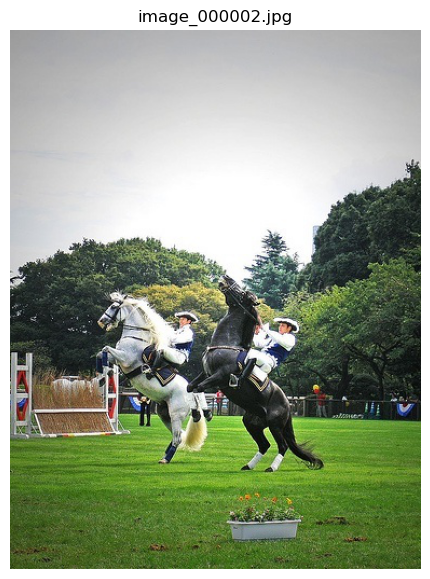

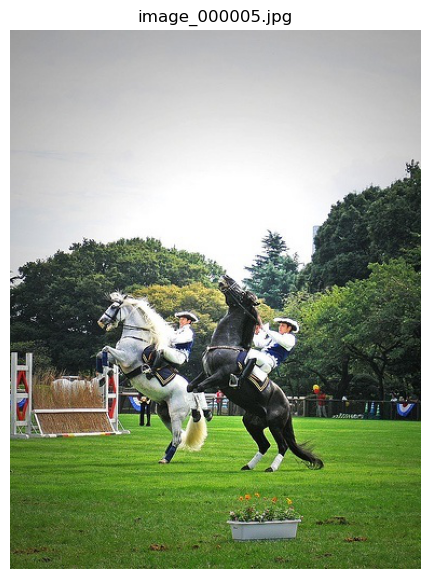

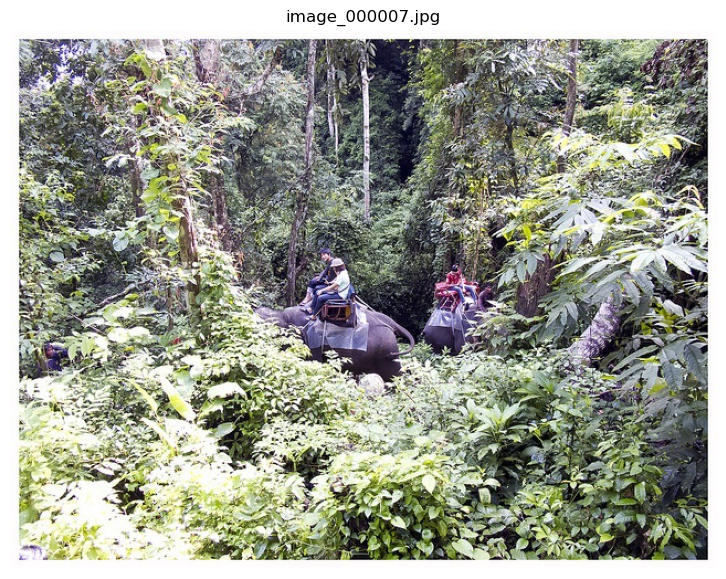

In [9]:
from PIL import Image
import matplotlib.pyplot as plt
import os

results_folder = r"D:\Smartvision_project\yolo_predictions\validation_results"

# Get first 3 result images
image_files = [
    f for f in os.listdir(results_folder)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
][:3]

print("Showing:", image_files)

for image_file in image_files:
    image_path = os.path.join(results_folder, image_file)

    img = Image.open(image_path)

    plt.figure(figsize=(10, 7))
    plt.imshow(img)
    plt.title(image_file)
    plt.axis("off")
    plt.show()

In [10]:
import os
import shutil

source = r"D:\Smartvision_project\runs\detect\smartvision_yolo\yolov8n_25class\weights\best.pt"

final_folder = r"D:\Smartvision_project\final_models"
os.makedirs(final_folder, exist_ok=True)

destination = os.path.join(final_folder, "smartvision_yolov8n_25class_best.pt")

shutil.copy2(source, destination)

print("✅ FINAL YOLO MODEL SAVED")
print(destination)

✅ FINAL YOLO MODEL SAVED
D:\Smartvision_project\final_models\smartvision_yolov8n_25class_best.pt
